In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].map({
    0: target_names[0],
    1: target_names[1],
    2: target_names[2]
})

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


In [3]:

print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("\nClass distribution:")
print(df["species"].value_counts())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Summary statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%         

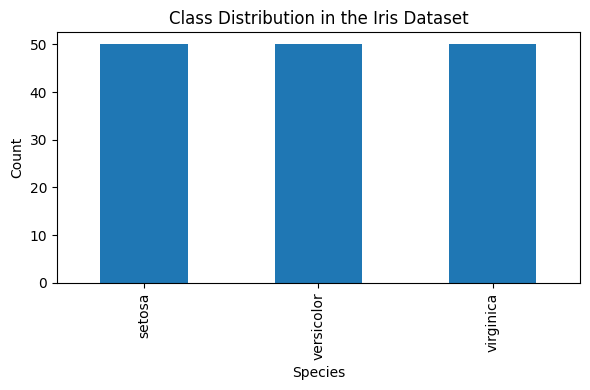

In [4]:

plt.figure(figsize=(6, 4))
df["species"].value_counts().plot(kind="bar")
plt.title("Class Distribution in the Iris Dataset")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

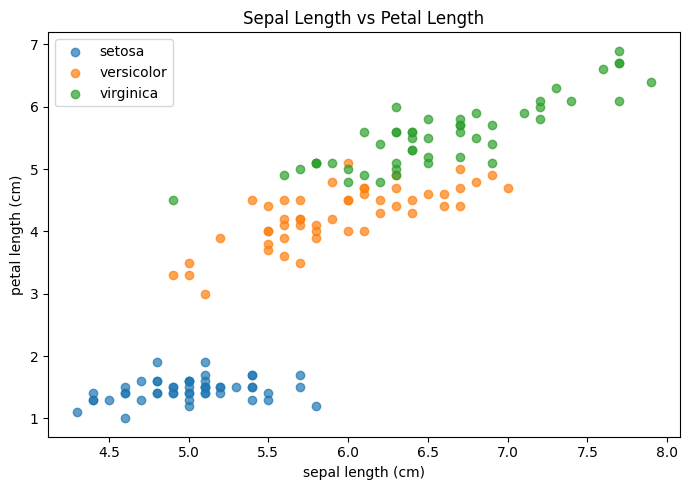

In [5]:

colors = ["red", "green", "blue"]

plt.figure(figsize=(7, 5))
for i, species in enumerate(target_names):
    plt.scatter(
        X[y == i, 0],   # sepal length
        X[y == i, 2],   # petal length
        label=species,
        alpha=0.7
    )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.title("Sepal Length vs Petal Length")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (120, 4)
Testing set shape: (30, 4)


In [7]:

kernels = ["linear", "poly", "rbf"]
results = []

trained_models = {}

for kernel in kernels:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=kernel, probability=True, random_state=42))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Kernel": kernel,
        "Accuracy": acc
    })

    trained_models[kernel] = model

results_df = pd.DataFrame(results)
print(results_df)

   Kernel  Accuracy
0  linear  1.000000
1    poly  0.900000
2     rbf  0.966667


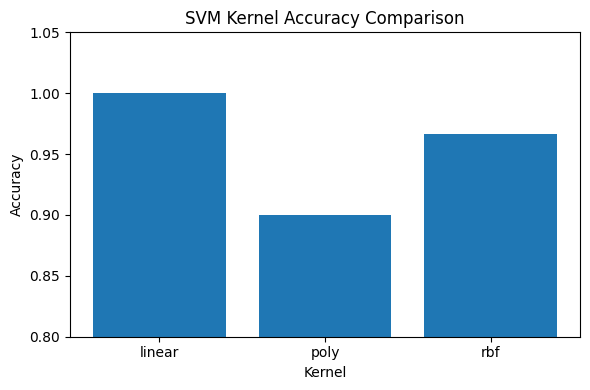

In [8]:

plt.figure(figsize=(6, 4))
plt.bar(results_df["Kernel"], results_df["Accuracy"])
plt.title("SVM Kernel Accuracy Comparison")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.05)
plt.tight_layout()
plt.show()

In [9]:

best_kernel = results_df.loc[results_df["Accuracy"].idxmax(), "Kernel"]
best_model = trained_models[best_kernel]

print("Best kernel:", best_kernel)

Best kernel: linear


In [10]:

y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=target_names))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



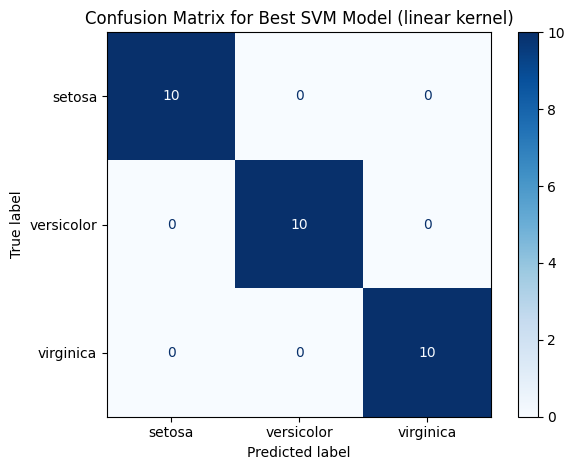

In [11]:

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix for Best SVM Model ({best_kernel} kernel)")
plt.tight_layout()
plt.show()

In [12]:

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

param_grid = {
    "svm__kernel": ["linear", "rbf", "poly"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"],
    "svm__degree": [2, 3, 4]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print("\nBest cross-validation score:")
print(grid.best_score_)

Best parameters:
{'svm__C': 0.1, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Best cross-validation score:
0.975


In [13]:

best_tuned_model = grid.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)

print("Tuned model test accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report for Tuned Model:\n")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

Tuned model test accuracy: 0.9333333333333333

Classification Report for Tuned Model:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



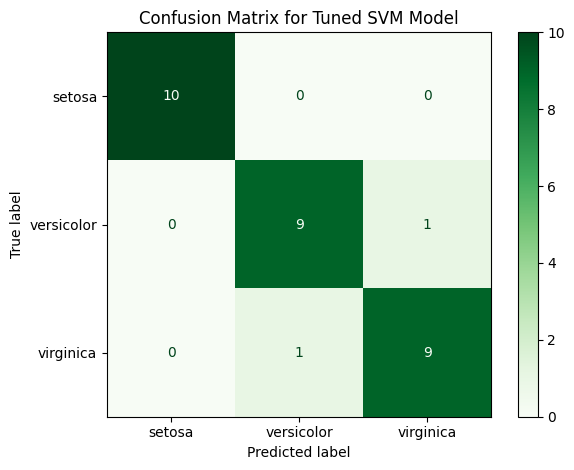

In [14]:

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=target_names)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix for Tuned SVM Model")
plt.tight_layout()
plt.show()

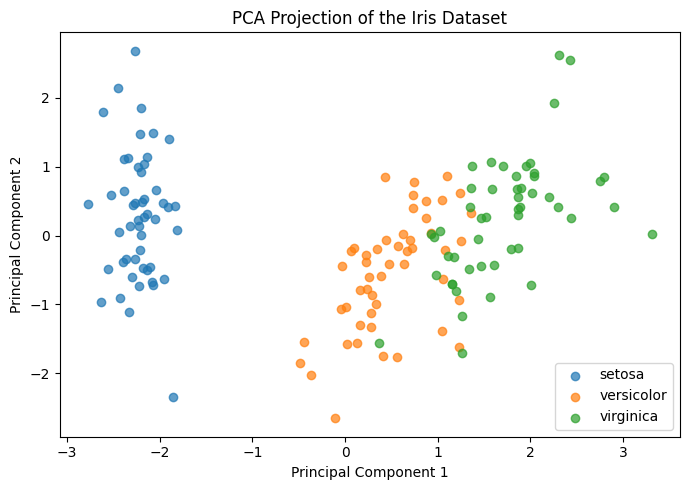

In [16]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["species"] = [target_names[i] for i in y]

plt.figure(figsize=(7, 5))
for species in target_names:
    subset = pca_df[pca_df["species"] == species]
    plt.scatter(subset["PC1"], subset["PC2"], label=species, alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of the Iris Dataset")
plt.legend()
plt.tight_layout()
plt.show()

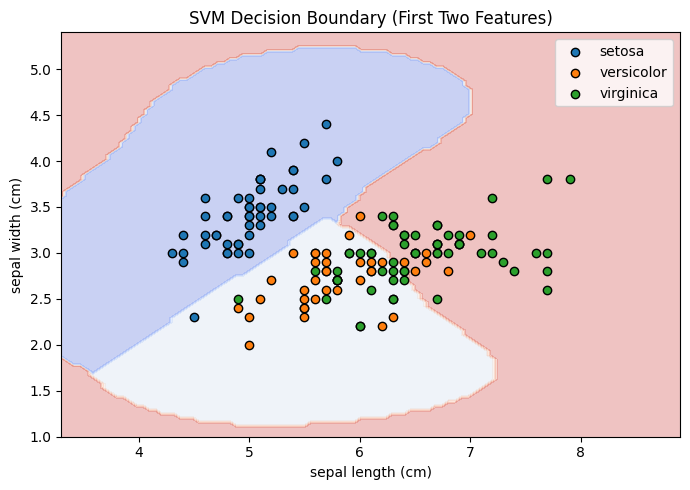

In [17]:

X_2d = X[:, :2]
y_2d = y

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

svm_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

svm_2d.fit(X_train_2d, y_train_2d)

plt.figure(figsize=(7, 5))
ax = plt.gca()

DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_2d,
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.3,
    ax=ax
)

for i, species in enumerate(target_names):
    plt.scatter(
        X_2d[y_2d == i, 0],
        X_2d[y_2d == i, 1],
        label=species,
        edgecolor="k"
    )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("SVM Decision Boundary (First Two Features)")
plt.legend()
plt.tight_layout()
plt.show()

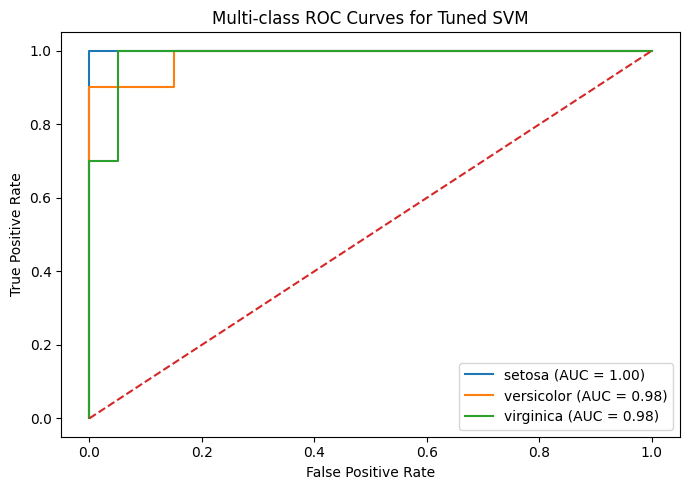

In [18]:

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

y_score = best_tuned_model.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 5))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{target_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves for Tuned SVM")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:

summary_data = {
    "Model": ["Linear SVM", "Polynomial SVM", "RBF SVM", "Tuned SVM"],
    "Accuracy": [
        results_df.loc[results_df["Kernel"] == "linear", "Accuracy"].values[0],
        results_df.loc[results_df["Kernel"] == "poly", "Accuracy"].values[0],
        results_df.loc[results_df["Kernel"] == "rbf", "Accuracy"].values[0],
        accuracy_score(y_test, y_pred_tuned)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df)

            Model  Accuracy
0      Linear SVM  1.000000
1  Polynomial SVM  0.900000
2         RBF SVM  0.966667
3       Tuned SVM  0.933333


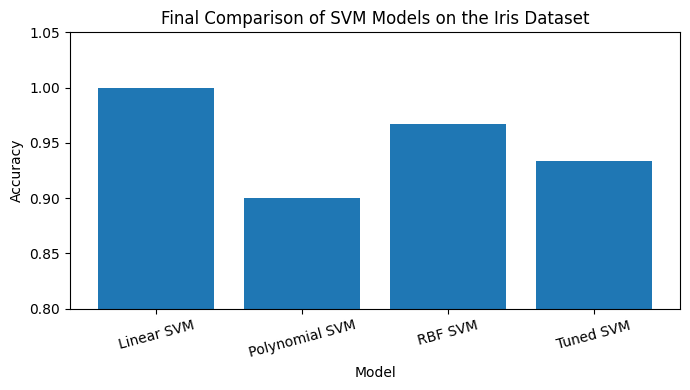

In [20]:

plt.figure(figsize=(7, 4))
plt.bar(summary_df["Model"], summary_df["Accuracy"])
plt.title("Final Comparison of SVM Models on the Iris Dataset")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()